## Supervised Learning
#### by **Ivan Alducin**
<p><img src="https://preview.redd.it/rfgtsej8fhv71.jpg?auto=webp&s=99a5d000ff2baaac79a8d15c7135c3677f105159" width="1000"></p>

## Exploratory Data Analysis
<p>Vamos a trabajar con el conjunto de datos de <code>Heart Attack</code>, el objetivo es predecir bajo que escenario es más probable que un paciente pueda tener un ataque al corazón  Un experto en medicina cardiovasuclar puede predecir esto sin hacer uso de <i>Machine Learning</i>, pero probablemente no instantáneamente, ¡y ciertamente no si estamos tratando con cientos o miles de muestras!.
    
A continuación una breve explicación de las variables del dataset:
    
- <b>age:</b> Age of the patient
- <b>sex:</b> Sex of the patient
- <b>cp:</b> Chest pain type ~ 0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic
- <b>trtbps:</b> Resting blood pressure (in mm Hg)
- <b>chol:</b> Cholestoral in mg/dl fetched via BMI sensor
- <b>fbs:</b> (fasting blood sugar > 120 mg/dl) ~ 1 = True, 0 = False
- <b>restecg:</b> Resting electrocardiographic results ~ 0 = Normal, 1 = ST-T wave normality, 2 = Left ventricular hypertrophy
- <b>thalachh:</b> Maximum heart rate achieved
- <b>oldpeak:</b> Previous peak
- <b>slp:</b> Slope
- <b>caa:</b> Number of major vessels
- <b>thall:</b> Thalium Stress Test result ~ (0,3)
- <b>exng:</b> Exercise induced angina ~ 1 = Yes, 0 = No
- <b>output:</b>  Target variable</p>

In [1]:
# Archivo Heart Attack.csv - ¿Cuales son los factores que pueden incrementar o disminuir la probabilidad de un ataque al corazón?

import pandas as pd

df = pd.read_csv("Heart Attack.csv")
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
import sweetviz as sv
my_report = sv.analyze(df, pairwise_analysis="off")
my_report.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## k-Nearest Neighbors
<p>Habiendo hecho un Análisis Exploratorio de los factores que pueden o no tener más posibilidad de un ataque al corazón, es hora de crear tu primer clasificador!!! usando el algoritmo de k-NN.
    
<b>Nota</b>: es importante garantizar que los datos esten en el formato requerido por la librería de <code>scikit-learn</code>. La información debe estar en una matriz en la que cada columna sea una variable y cada fila una observación diferente, en este caso, el registro de análisis clinico por paciente. Y la variable objetivo debe ser una sola columna con el mismo número de observaciones.</p>

In [9]:
# Importa la librería para un clasificador k-NN de sklearn
import numpy as np
import matplotlib.pyplot as plt

# Crea dos arreglos "X", "y" que contengan los valores de las variables independientes y la variable objetivo
y = df.output.values
x_data = df.drop(["output"], axis=1)

#Normalización
columns = ["age", "trtbps", "chol", "thalachh", "oldpeak"]
for i in columns:
    x_data[i] = (x_data[i] - np.min(x_data[i])) / (np.max(x_data[i]) - np.min(x_data[i]))
x_data

# Crea un clasificador k-NN con 6 vecinos
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=6)

# Ajusta el clasificador a las variables
knn.fit(x_data, y)
prediction = knn.predict(x_data)
print("Score: ", knn.score(x_data, y))

#Creación de la matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, prediction)
cm

Score:  0.8910891089108911


array([[121,  17],
       [ 16, 149]], dtype=int64)

## Predicción
<p>Una vez que entrenamos al clasificador k-NN, ahora lo podemos usar para predecir un nuevo registro. Para este caso,  no hay datos sin clasificar disponibles ya que todos se usaron para entrenar al modelo. Para poder calcular una predicción, vamos a usar el método <code>.predict()</code> pero, para esto vamos a simular una observación completamente nueva</p>

In [25]:
# Crea un arreglo simulando una observación
columnas_dataframe = x_data.columns
x_new = np.empty(shape=(1,13))
for i in range(len(columnas_dataframe)):
    x_new[0][i] = x_data[columnas_dataframe[i]].sample(n=1)

#Predice la clasificación para el arreglo que creaste
y_new_pred = knn.predict(x_new)
print("Prediction: {}".format(y_new_pred))

Prediction: [1]


C:\Users\yair_\AppData\Local\Temp\ipykernel_2304\2645409353.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x_new[0][i] = x_data[columnas_dataframe[i]].sample(n=1)
C:\Users\yair_\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Reconocimiento de digitos
<p>Hasta ahora, solo hemos realizado una clasificación binaria, ya que la variable objetivo tenía dos resultados posibles. En los siguientes ejercicios, trabajarás con el conjunto de datos de reconocimiento de dígitos MNIST, que tiene 10 clases, ¡los dígitos del 0 al 9! Una versión reducida del conjunto de datos <a href="http://yann.lecun.com/exdb/mnist/">MNIST</a> es uno de los conjuntos de datos incluidos en <code>scikit-learn</code>

Cada muestra de este conjunto de datos es una imagen de 28x28 que representa un dígito escrito a mano. Cada píxel está representado por un número entero en el rango de 1 a 784, lo que indica niveles variables de negro.

<p><img src="https://miro.medium.com/max/1400/1*hVdoiW35FXUE-fZ0HI30Tw.jpeg" width="350"></p>

In [26]:
# Importa el archivo de MNIST
digits = pd.read_csv("MNIST.csv")
digits

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
# Crea una variable 'cols' para hacer referencia a todas las columnas que contienen la palabra 'pixel'
df = digits.drop(["label"], axis=1)
cols = list(df.columns.values)

El número es: 4


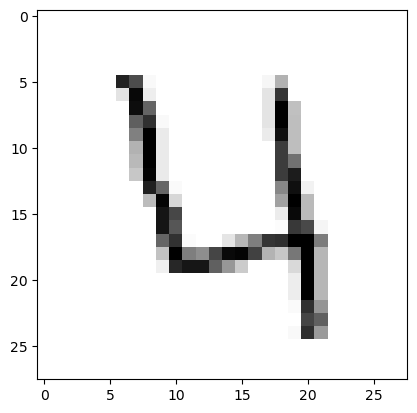

In [31]:
# Vamos a imprimir un digito
print("El número es:", digits.iloc[3, 0])
plt.imshow(digits.loc[3, cols].values.reshape((28,28)).astype(float), cmap=plt.cm.gray_r, interpolation='nearest')

## Train/Test
<p>Una de las principales diferencias entre la Estadística Clasica y el <i>Machine Learning</i> es la división del conjunto de datos en conjuntos de entrenamiento y prueba, con el objetivo de medir y cuantificar la precisión y el nivel de error en los datos que de alguna manera el modelo <i>"No ha visto"</i>. A continuación crearemos nuestros conjuntos de entrenamiento y prueba con el método <code>train_test_split</code> y mediremos cual es el nivel de precisión de nuestro modelo. El objetivo es <b>predecir cual es el digito dada una imagen</b>!!!. Para lo cual entrenaremos un clasificador <i>k-NN</i> a los datos de entrenamiento y luego calcularemos su precisión usando el método <code>accuracy_score()</code> en los datos de prueba ¿Como crees que en un modelo de Clasificación se calcule su precisión?. Parece bastante dificil, pero no lo es ;)</p>

In [36]:
# Importa la librería para entrenamiento y prueba de datos y la librería para calcular la precisión
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [37]:
# Crea los arreglos para las variables independientes y la variable objetivo
y = digits.label.values
x = digits.drop(["label"], axis=1)

# Divide los arreglos anteriores en conjuntos de training y test en una proporcion del 70/30
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=1)

# Instancia un clasificador k-NN con 14 vecinos
knn = KNeighborsClassifier(n_neighbors=14)

# Ajusta (Entrenamiento) el clasificador en el conjunto de entrenamiento
knn.fit(x_train, y_train)

# Calcular las predicciones sobre el conjunto de prueba
y_pred = knn.predict(x_test)

# Verificar la precisión del modelo 
print(accuracy_score(y_test, y_pred))

0.9607142857142857


## Reconocimiento de tu imagen
<p>Con todo lo anterior, podemos hacer el reconocimiento de cualquier digito que dibujes, ¿Estás list@?</p>

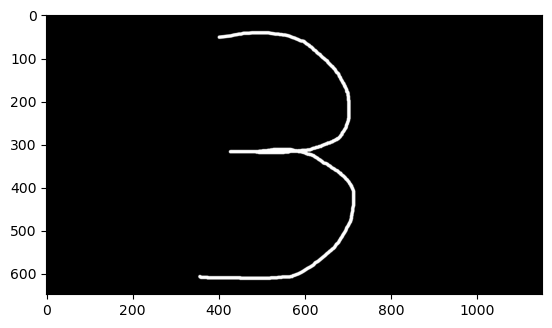

In [38]:
# Vamos a visualizar la imagen de un número que vas a crear en tu computador con la aplicación de paint, ésta imagen debe de tener un fondo negro y ser pintada en blanco, encontrarás un ejemplo en el repositorio
image = plt.imread("numero.jpg") # Coloca aquí la ruta de la imagen que hayas creado en formato jpg o png
plt.imshow(image)

In [39]:
# Con esta libreria transformaremos la imagen creada a un formato de 28x28 pixeles
from PIL import Image
pil = Image.open("numero.jpg")
image_resize = pil.resize((28, 28))

# Vamos transformar la nueva imagen en un array donde se almacenara la información de los pixeles
pixels = np.asarray(image_resize)

In [40]:
# Necesitamos hacer algunas configuraciones a la imagen debido al formato de datos que esta alimentando al modelo y a la configuración de sklearn
arr = pixels.transpose(2, 0, 1).reshape(-1, pixels.shape[1])[0:28]

image_final = arr.ravel().reshape(1, -1)

El número es: [1]


C:\Users\yair_\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


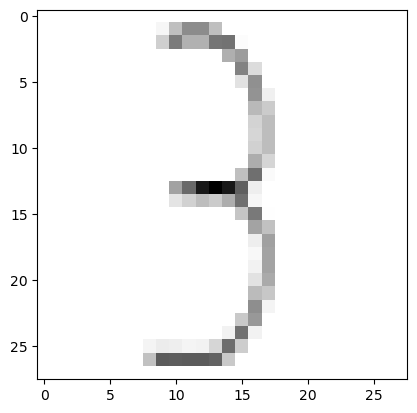

In [42]:
# Calcula la predicción del modelo con el número que creaste, ¿Fue la clasificación correcta? :O
pred = knn.predict(image_final)
print("El número es:", pred)
plt.imshow(arr, cmap=plt.cm.gray_r, interpolation='nearest')

## Overfit and Underfit
<p>¿Cual es mi numero ideal para elegir el parametro <i>k</i>? Vamos a calcular los valores de precisión para los conjuntos e entrenamiento y prueba para una rango de valores k. Al observar cómo difieren estos valores podremos observar cual es el mejor parametro sin caer en un <i>Overfit</i> o un <i>Underfit</i>.</p>

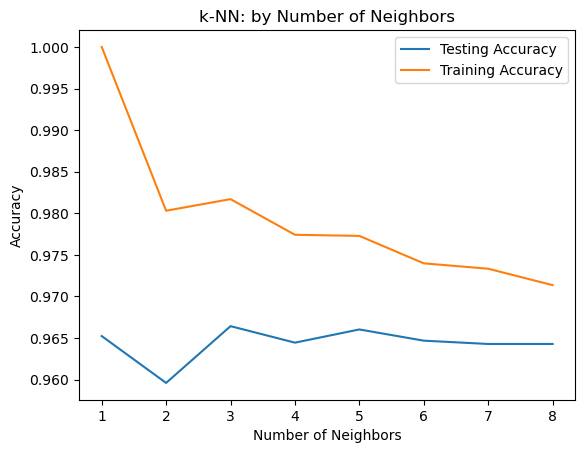

In [43]:
# Coniguración de arreglos iniciales
neighbors = np.arange(1, 9)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

# Loop para diferentes valores de k
for i, k in enumerate(neighbors):
    # Clasificador k-NN para el parametro k
    knn = KNeighborsClassifier(n_neighbors=k)

    # Ajuste del clasificador al dataset de entrenamiento
    knn.fit(x_train, y_train)
    
    # Calculo de precision sobre el dataset de entrenamiento
    train_accuracy[i] = knn.score(x_train, y_train)

    # Calculo de precision sobre el dataset de prueba
    test_accuracy[i] = knn.score(x_test, y_test)

# Grafico para encontrar un valor optimo de k
plt.plot(neighbors, test_accuracy, label = 'Testing Accuracy')
plt.plot(neighbors, train_accuracy, label = 'Training Accuracy')
plt.title('k-NN: by Number of Neighbors')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Regresión Logística
<p>Haz la predicción de tu imagen, pero esta vez por medio de una Regresión Logística, ¿Cuál de los dos modelos te da mejores resultados?</p>

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

In [48]:
#Utilizando solver lbfgs
model = LogisticRegression(solver="lbfgs")
clf = model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Intercepto (Beta 0): ", clf.intercept_)
print("Pesos (Betas): ", clf.coef_)
print("-----------------------------------------------")
score = model.score(x_test, y_test)
print("Precisión global: ", score)
print("-----------------------------------------------")
print(classification_report(y_test, y_pred))

Intercepto (Beta 0):  [-7.78818400e-05  6.07943942e-05  6.01540941e-05 -8.62421816e-05
  2.69013195e-05  4.09592775e-04 -1.89977423e-05  1.44234381e-04
 -4.32842502e-04 -8.57126977e-05]
Pesos (Betas):  [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
-----------------------------------------------
Precisión global:  0.919047619047619
-----------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1247
           1       0.96      0.97      0.97      1395
           2       0.93      0.91      0.92      1257
           3       0.91      0.89      0.90      1321
           4       0.92      0.93      0.92      1232
           5       0.88      0.85      0.86      1111
           6       0.95      0.96      0.96      1258
           7       0.93      0.93      0.93      1285
           8       0.8

El número es: [9]


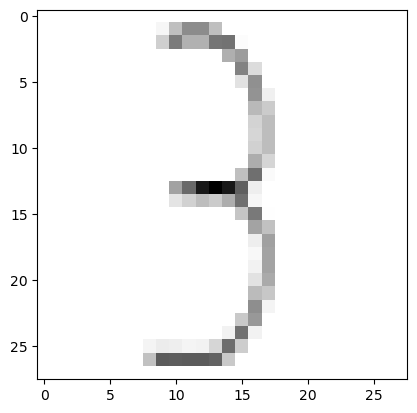

In [52]:
# Calcula la predicción del modelo de regresión logística con el número que creaste, ¿Fue la clasificación correcta? :O
pred = model.predict(image_final)
print("El número es:", pred)
plt.imshow(arr, cmap=plt.cm.gray_r, interpolation='nearest')

### ¿Cuál de los dos modelos te da mejores resultados?

De acuerdo con la precisión global de ambos modelos, el modelo que se ajustó de mejor manera a los datos es el KNN con un 96.07% de precisión. Sin embargo, para mi caso práctico, con ninguno de los dos modelos logré predecir el número que había dibujado, supongo que puede ser por el tamaño o herramienta que utilicé para dibujarlo, que no estaba en las mismas condiciones que los dibujos de la base de datos.

Agradecería si me ayudan a entender por qué no tuve éxito en predecir mi imagen, a pesar de que los score de ambos modelos eran buenos.

Por otro lado, para hacer el análisis de datos exploratorio, hice de todo y no logré instalar el dataprep. Les solicité ayuda pero los pasos que me recomendaban hacer no me funcionaron. No sé si sea posible tener una sesión con alguien para solucionar este problema, ya que si veo importante que logré hacer funcionar esta herramienta. Busqué otras alternativas para hacer el análisis exploratorio, y opté por utilizar "sweetviz" (adjunto el reporte que me generó).